In [2]:
import pandas as pd 
import seaborn as sns
import numpy as np
import matplotlib.pyplot  as plt

In [3]:
print("=" * 60)
print("PHẦN 1: EDA")
print("=" * 60)

PHẦN 1: EDA


In [4]:
df = pd.read_csv("data/heart_disease.csv")

print(f"Dataset có {df.shape[0]} hàng và {df.shape[1]} cột")
print("Danh sách các cột:")
for col in df.columns:
    print(f"Cột: {col}")
    
print(f"\n{df.info()}")
print(f"\n{df.describe().round(2)}")
print(f"\n5 dòng đầu:\n{df.head()}")


Dataset có 2000 hàng và 12 cột
Danh sách các cột:
Cột: age
Cột: gender
Cột: bmi
Cột: blood_pressure
Cột: cholesterol
Cột: blood_sugar
Cột: smoking
Cột: family_history
Cột: physical_activity
Cột: alcohol
Cột: stress_level
Cột: heart_disease
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                2000 non-null   int64  
 1   gender             2000 non-null   object 
 2   bmi                1916 non-null   float64
 3   blood_pressure     2000 non-null   object 
 4   cholesterol        1903 non-null   float64
 5   blood_sugar        1888 non-null   float64
 6   smoking            2000 non-null   object 
 7   family_history     2000 non-null   int64  
 8   physical_activity  2000 non-null   object 
 9   alcohol            1060 non-null   object 
 10  stress_level       2000 non-null   int64  
 11  heart_disease      2000 

In [5]:
mapping = {0: 'Không bị bệnh', 1: 'Có bị bệnh'}
diag_list = df['heart_disease'].value_counts().rename(index = mapping)
print(f"{diag_list} - tỷ lệ: {diag_list / df['heart_disease'].count() * 100 } ")

heart_disease
Không bị bệnh    1736
Có bị bệnh        264
Name: count, dtype: int64 - tỷ lệ: heart_disease
Không bị bệnh    86.8
Có bị bệnh       13.2
Name: count, dtype: float64 


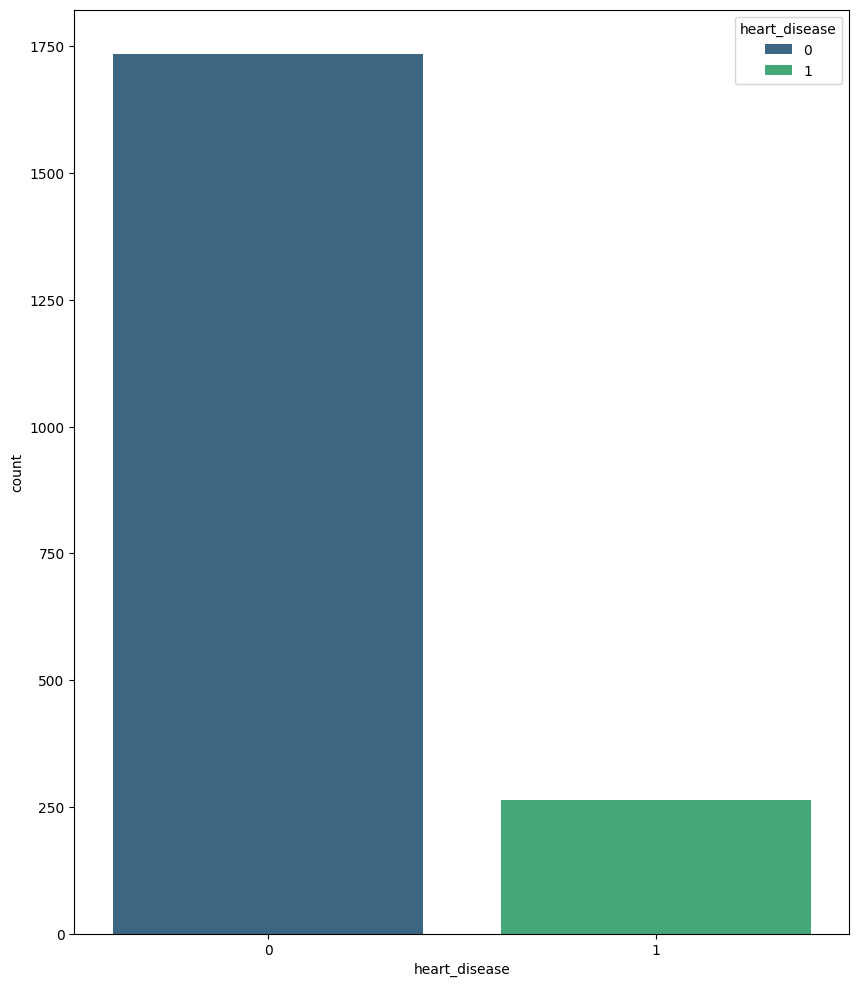

In [6]:
plt.figure(figsize = (10,12))
sns.countplot(
    data = df,
    x = 'heart_disease',
    hue='heart_disease',
    palette='viridis'
)
plt.show()

In [7]:
missing_value = df.isnull().sum()
percent = missing_value / df['gender'].count() * 100
print(f"Số lượng hàng dữ liệu bị thiếu: {missing_value} - \ntỷ lệ \n{round(percent, 2)}")
duplicated_value = df.duplicated().sum()
print(f"So hang bi trung  {duplicated_value}")

Số lượng hàng dữ liệu bị thiếu: age                    0
gender                 0
bmi                   84
blood_pressure         0
cholesterol           97
blood_sugar          112
smoking                0
family_history         0
physical_activity      0
alcohol              940
stress_level           0
heart_disease          0
dtype: int64 - 
tỷ lệ 
age                   0.00
gender                0.00
bmi                   4.20
blood_pressure        0.00
cholesterol           4.85
blood_sugar           5.60
smoking               0.00
family_history        0.00
physical_activity     0.00
alcohol              47.00
stress_level          0.00
heart_disease         0.00
dtype: float64
So hang bi trung  0


In [8]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

features_numeric = numeric_cols.drop('heart_disease')

for col in features_numeric:
    if df[col].nunique() > 10:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        
        upper = q3 + 1.5 * iqr
        lower = q1 - 1.5 * iqr
        
        outliers = (df[col] < lower) | (df[col] > upper)
        
        if outliers.any():
            print(f"Cột {col:15} | Outliers: {outliers.sum():<5} | Biên: [{lower:>6.1f}, {upper:>6.1f}]")
            df[col] = df[col].clip(lower=lower, upper=upper)

Cột bmi             | Outliers: 15    | Biên: [  10.8,   43.8]
Cột cholesterol     | Outliers: 11    | Biên: [  86.5,  314.5]
Cột blood_sugar     | Outliers: 6     | Biên: [  27.5,  183.5]


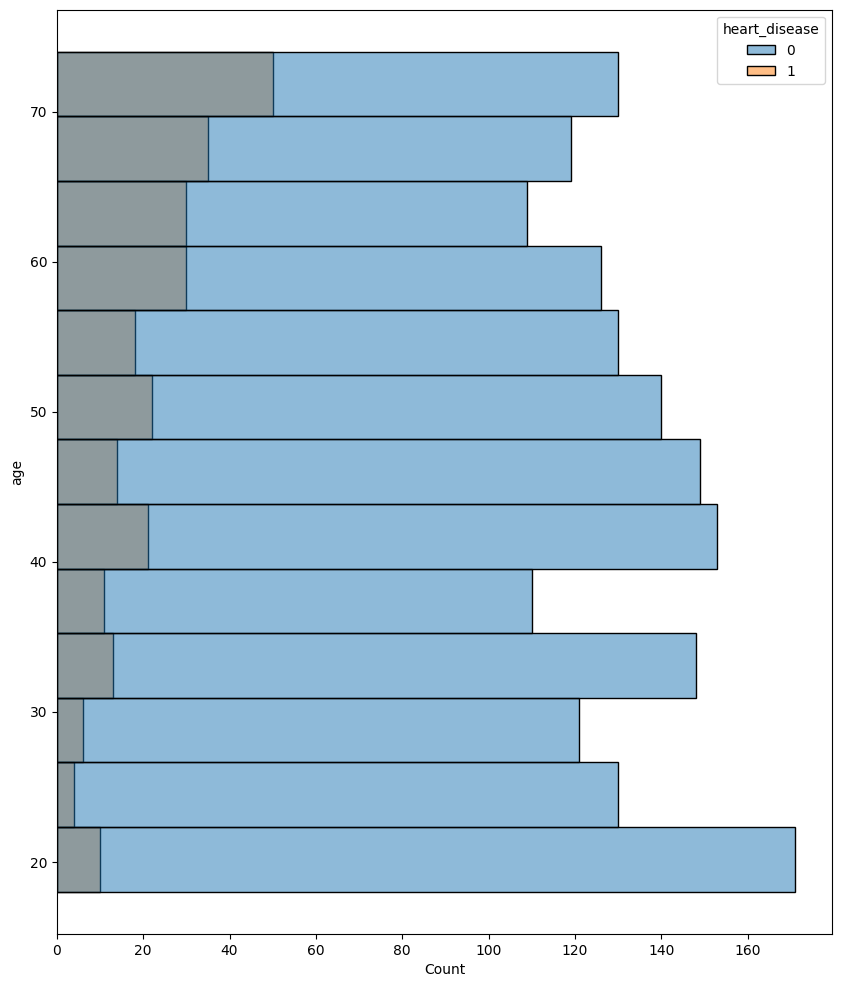

In [9]:
plt.figure(figsize = (10,12))
sns.histplot(
    data = df,
    y = 'age',
    hue = 'heart_disease'
)
plt.show()

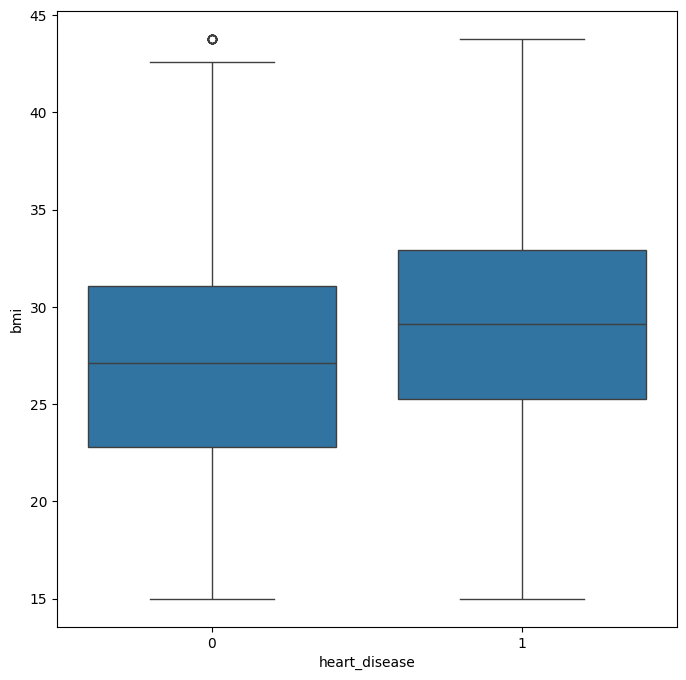

In [10]:
plt.figure(figsize=(8,8))
sns.boxplot(
    data = df,
    x = 'heart_disease',
    y = 'bmi'
)
plt.show()

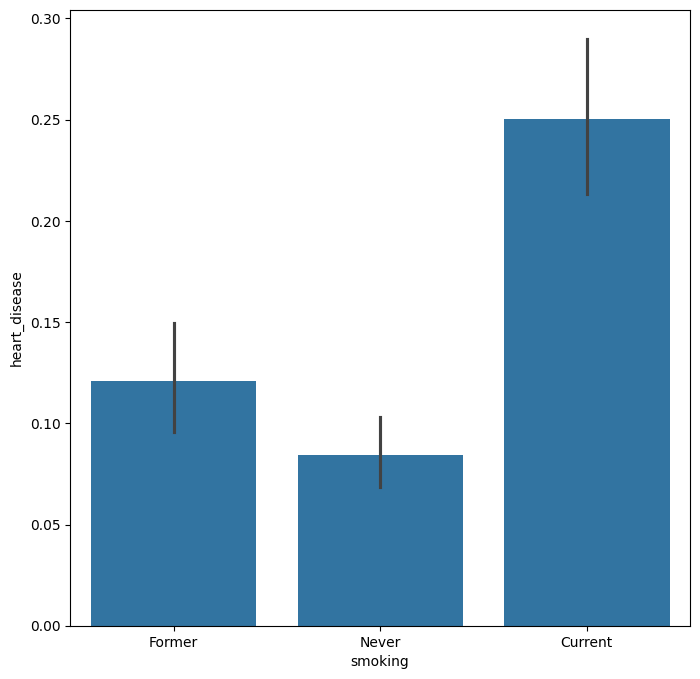

In [11]:
plt.figure(figsize=(8,8))
sns.barplot(
    data=df,
    y = 'heart_disease',
    x = 'smoking'
)
plt.show()

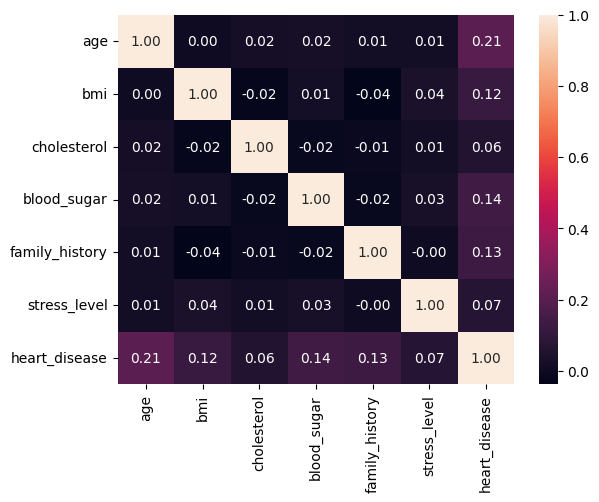

In [12]:
sns.heatmap(
    data = df.select_dtypes(include=['float64', 'int64']).corr(),
    annot=True,
    fmt=".2f"
)

plt.show()

In [13]:
print("=" * 60)
print("PHẦN 2: PREPROCESSING")
print("=" * 60)

PHẦN 2: PREPROCESSING


In [14]:
bmi_medians = df.groupby('blood_pressure')['bmi'].transform('median')

df['bmi'] = df['bmi'].fillna(bmi_medians)
df['cholesterol'] = df['cholesterol'].fillna(df['cholesterol'].median())
df['blood_sugar'] = df['blood_sugar'].fillna(df['blood_sugar'].median())
df['alcohol'] = df['alcohol'].fillna(df['alcohol'].mode()[0])

In [15]:
def bmi_category(bmi):
    if bmi < 18.5: return 'Underweight'
    elif bmi < 25:  return 'Normal'
    elif bmi < 30:  return 'Overweight'
    else:           return 'Obese'
    
df['bmi_category'] = df['bmi'].apply(bmi_category)

df['risk_score'] = (
    (df['blood_pressure'] == 'High').astype(int) * 2 +
    (df['smoking'] == 'Current').astype(int) * 2 +
    df['family_history'] +
    (df['physical_activity'] == 'Low').astype(int)
)

In [17]:
encode_col = ['gender', 'blood_pressure', 'smoking', 'physical_activity', 'alcohol', 'bmi_category']

df_encoded = pd.get_dummies(df, encode_col, dtype=int)

print(df_encoded.head())

   age   bmi  cholesterol  blood_sugar  family_history  stress_level  \
0   56  22.9        233.0        102.0               0             6   
1   69  27.2        233.0        173.0               0             7   
2   46  31.6        238.0         99.0               0             5   
3   32  26.2        249.0        100.0               0            10   
4   60  33.9        288.0         62.0               1             8   

   heart_disease  risk_score  gender_Female  gender_Male  ...  smoking_Never  \
0              0           0              0            1  ...              0   
1              0           0              1            0  ...              0   
2              0           0              1            0  ...              1   
3              0           2              0            1  ...              1   
4              1           4              1            0  ...              1   

   physical_activity_High  physical_activity_Low  physical_activity_Moderate  \
0     

In [20]:
print(df_encoded.shape)
print(df_encoded.isnull().sum().sum())

(2000, 25)
0


In [21]:
print("=" * 60)
print("PHẦN 3: TRAIN VÀ ĐÁNH GIÁ")
print("=" * 60)

PHẦN 3: TRAIN VÀ ĐÁNH GIÁ


In [26]:
from sklearn.model_selection import train_test_split

features_col = numeric_cols.drop('heart_disease')
X = df_encoded[features_col]
y = df_encoded['heart_disease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify = y)
print(f"\nTrain: {X_train.shape[0]} | Test: {X_test.shape[0]}")


Train: 1600 | Test: 400


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, recall_score, precision_score

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_A = LogisticRegression(max_iter=1000, random_state=42)
model_A.fit(X_train_scaled, y_train)

model_B = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model_B.fit(X_train_scaled, y_train)

y_train_pred = model_A.predict(X_train_scaled)
y_test_pred  = model_A.predict(X_test_scaled)


acc_train =  accuracy_score(y_train, y_train_pred)
acc_test =  accuracy_score(y_test, y_test_pred)
recall_train =  recall_score(y_train, y_train_pred)
recall_test =  recall_score(y_test, y_test_pred)
precision_train =  precision_score(y_train, y_train_pred)
precision_test =  precision_score(y_test, y_test_pred)
mse_train  = mean_squared_error(y_train, y_train_pred)
mse_test   = mean_squared_error(y_test, y_test_pred)
rmse_train = np.sqrt(mse_train)
rmse_test  = np.sqrt(mse_test)
r2_train   = r2_score(y_train, y_train_pred)
r2_test    = r2_score(y_test, y_test_pred)

print(f"\n{'Metric':<20}{'Train':>12}{'Test':>12}")
print("-" * 44)
print(f"{'Acc':<20}{acc_train:>12.0f}{acc_test:>12.0f}")
print(f"{'Acc':<20}{recall_train:>12.0f}{recall_test:>12.0f}")
print(f"{'Acc':<20}{precision_train:>12.0f}{precision_test:>12.0f}")
print(f"{'MSE':<20}{mse_train:>12.0f}{mse_test:>12.0f}")
print(f"{'RMSE':<20}{rmse_train:>12.2f}{rmse_test:>12.2f}")
print(f"{'R²':<20}{r2_train:>12.4f}{r2_test:>12.4f}")



Metric                     Train        Test
--------------------------------------------
Acc                            1           1
Acc                            0           0
Acc                            1           0
MSE                            0           0
RMSE                        0.36        0.37
R²                       -0.1192     -0.1745


PHẦN 1: EDA
Shape: (2000, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                2000 non-null   int64  
 1   gender             2000 non-null   object 
 2   bmi                1916 non-null   float64
 3   blood_pressure     2000 non-null   object 
 4   cholesterol        1903 non-null   float64
 5   blood_sugar        1888 non-null   float64
 6   smoking            2000 non-null   object 
 7   family_history     2000 non-null   int64  
 8   physical_activity  2000 non-null   object 
 9   alcohol            1060 non-null   object 
 10  stress_level       2000 non-null   int64  
 11  heart_disease      2000 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 187.6+ KB

None

           age      bmi  cholesterol  blood_sugar  family_history  \
count  2000.00  1916.00      1903.00      1888.00  

C:\Users\lequa\AppData\Local\Temp\ipykernel_13244\1220929299.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='heart_disease', y='bmi',
C:\Users\lequa\AppData\Local\Temp\ipykernel_13244\1220929299.py:94: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,0].set_xticklabels(['Không bệnh (0)', 'Có bệnh (1)'])


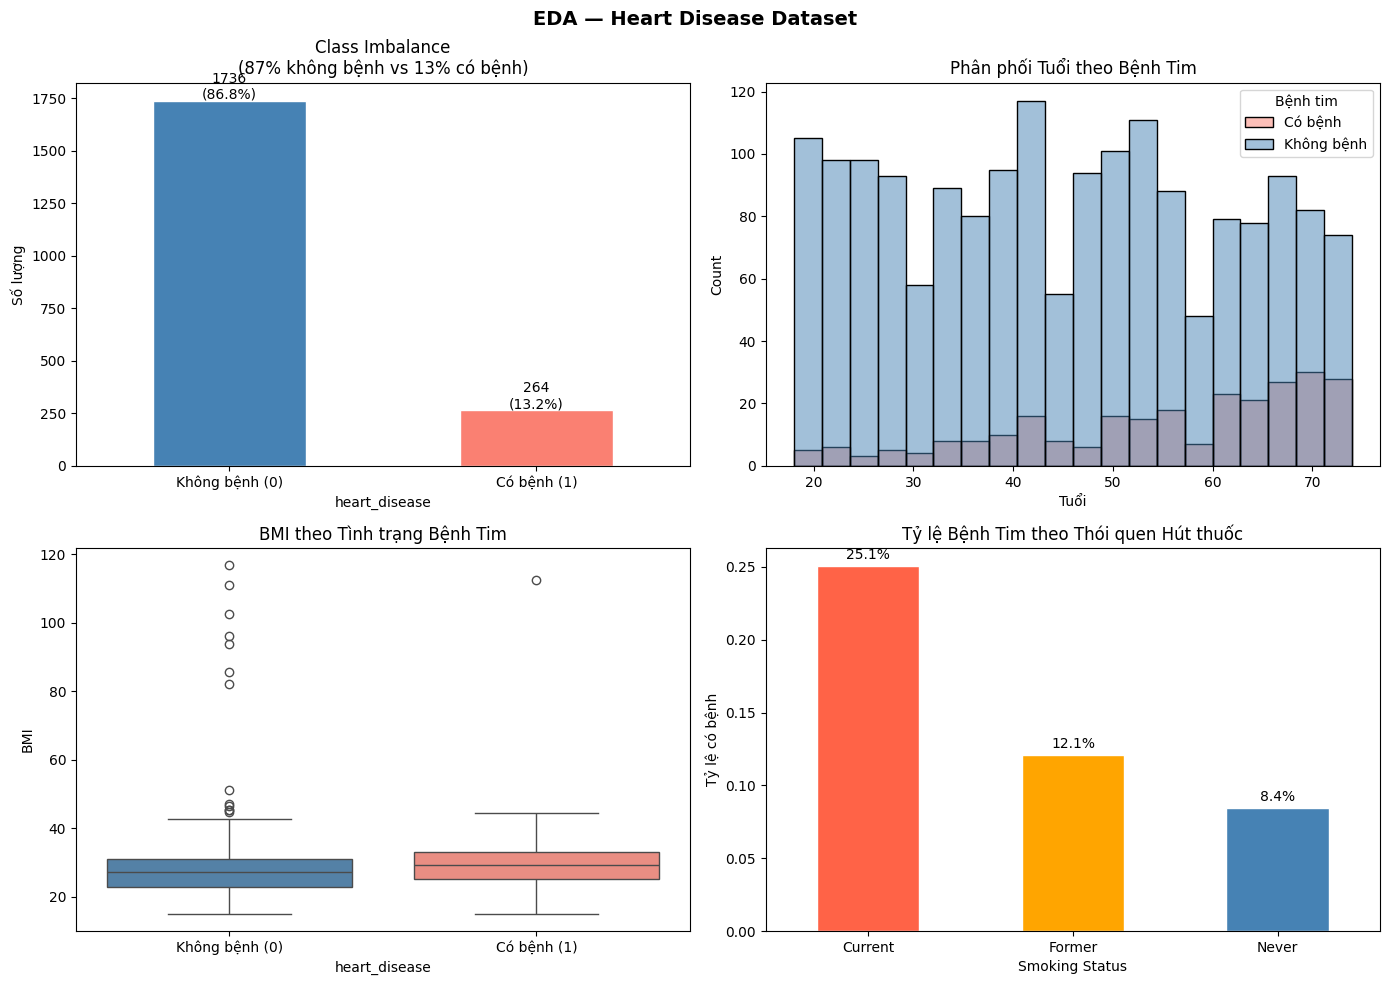

✅ Saved: output/eda_charts.png


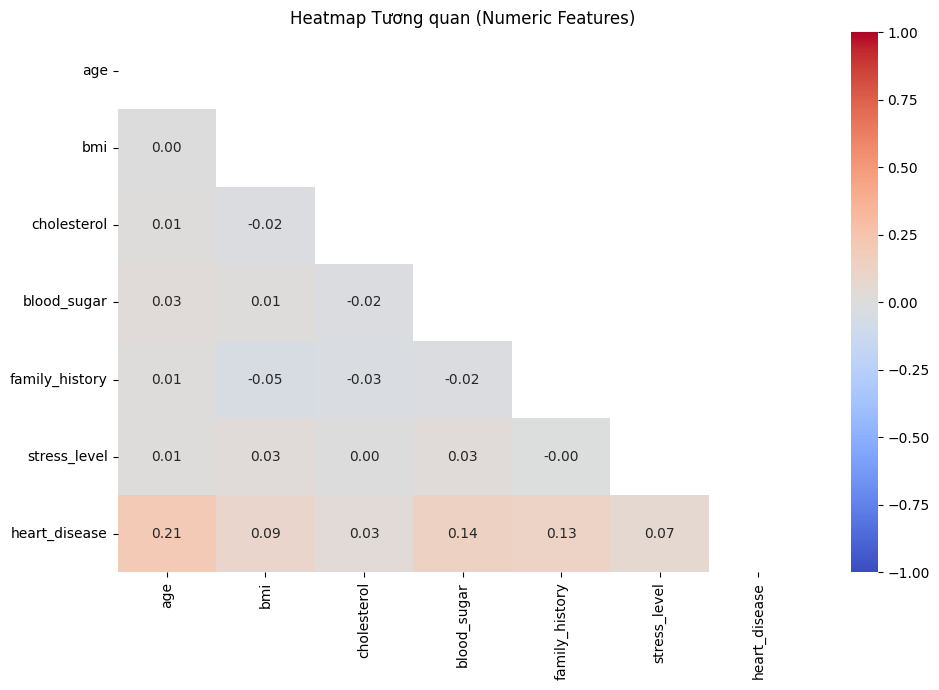


PHẦN 2: PREPROCESSING
Dropped 15 outlier rows → còn 1985 rows
Missing sau fill: 0
risk_score range: 0 – 6
Shape sau encoding: (1985, 19)
Null còn lại: 0

PHẦN 3: TRAIN & EVALUATE
Features: 18 cột
Train: 1588 | Test: 397

Metric                Model A (baseline)  Model B (balanced)
Accuracy                          0.8917              0.7632
Precision                         0.8571              0.3119
Recall                            0.2264              0.6415
F1                                0.3582              0.4198
ROC-AUC                           0.8216              0.8159

💬 Nhận xét Model A vs B:
  • Accuracy:  A cao hơn B (A=0.88 vs B=0.76)
               → ĐỪNG BI LỪA! A chủ yếu đoán "không bệnh" nên accuracy cao
  • Recall:    B cao hơn A RẤT NHIỀU (B=0.64 vs A=0.23)
               → B phát hiện được 64% ca bệnh thay vì chỉ 23%
  • ROC-AUC:   Gần bằng nhau → khả năng phân biệt tổng thể tương đương
  → Kết luận: Model B tốt hơn cho bài toán y tế vì Recall cao hơn nhiều

---

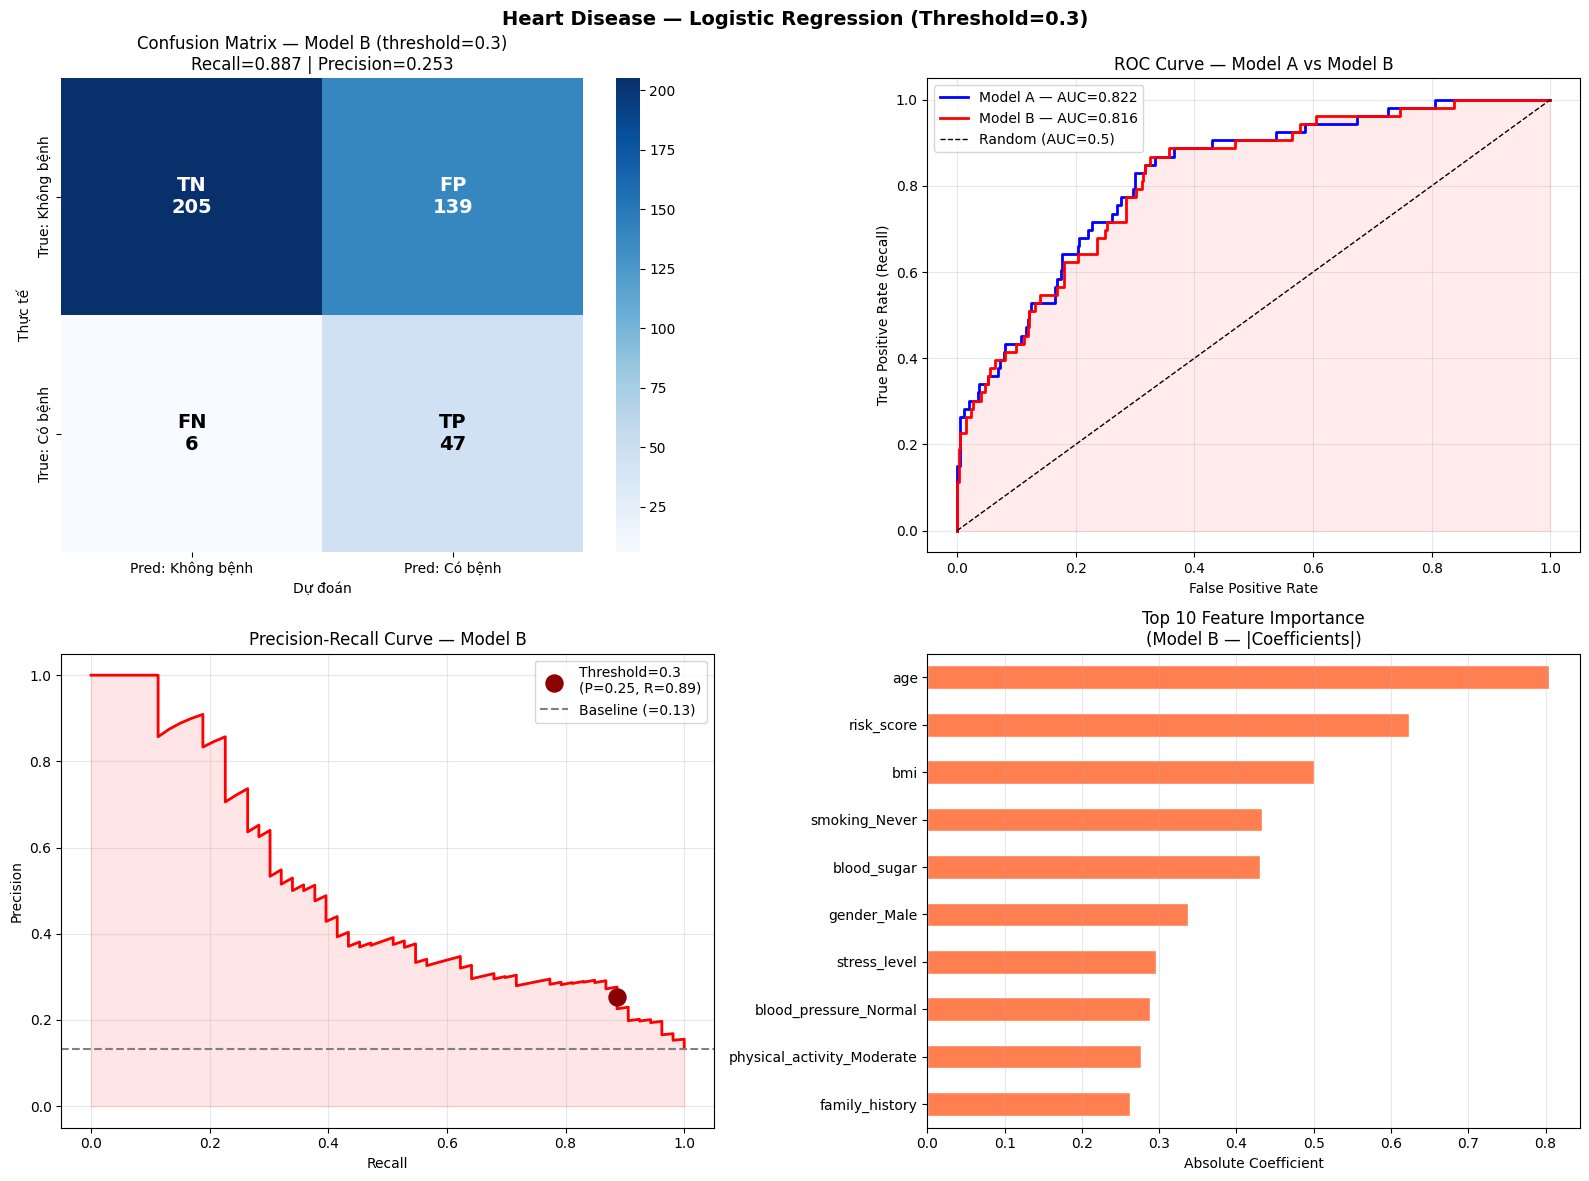

✅ Saved: output/model_charts.png

--- Bonus: Dự đoán bệnh nhân mới ---
  Nam 58t, béo phì, huyết áp cao, hút thuốc
    → Nguy cơ: High (98.5%) | ⚠️  CẢnh báo bác sĩ!

  Nữ 28t, khỏe mạnh, không có yếu tố nguy cơ
    → Nguy cơ: Low (4.5%) | ✅ Theo dõi định kỳ

  Nam 50t, tiền sử gia đình, cựu hút thuốc
    → Nguy cơ: High (63.3%) | ⚠️  CẢnh báo bác sĩ!



In [36]:
# ============================================================
# LỜI GIẢI CHUẨN — Dự đoán Nguy cơ Bệnh Tim
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, precision_recall_curve
)

# ============================================================
# PHẦN 1 — EDA
# ============================================================
print("=" * 60)
print("PHẦN 1: EDA")
print("=" * 60)

df = pd.read_csv("data/heart_disease.csv")
print(f"Shape: {df.shape}")
print(f"\n{df.info()}")
print(f"\n{df.describe().round(2)}")
print(f"\n5 dòng đầu:\n{df.head()}")

# 1.2 Phân tích class imbalance — QUAN TRỌNG: phải nhận xét
print("\n--- Class Imbalance ---")
counts = df['heart_disease'].value_counts()
pcts   = df['heart_disease'].value_counts(normalize=True) * 100
print(f"  Không bệnh (0): {counts[0]:>5}  ({pcts[0]:.1f}%)")
print(f"  Có bệnh    (1): {counts[1]:>5}  ({pcts[1]:.1f}%)")
print("""
  ⚠️  Nhận xét: Dataset bị imbalanced nghiêm trọng (~87:13).
  → Accuracy sẽ ảo: model luôn đoán "không bệnh" đạt 87% accuracy!
  → Phải dùng Recall, F1, ROC-AUC thay vì Accuracy làm metric chính.
""")

# 1.3 Missing values — đặc biệt chú ý alcohol 47%!
print("--- Missing Values ---")
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
report = pd.DataFrame({'Count': missing, 'Percent(%)': missing_pct})
print(report[report['Count'] > 0])
print("""
  ⚠️  Chú ý: alcohol có 47% missing — gần một nửa dữ liệu bị mất!
  Quyết định: vẫn giữ cột này vì alcohol là yếu tố nguy cơ quan trọng,
  fill bằng mode (giá trị phổ biến nhất).
""")

# 1.4 Kiểm tra outliers — CHỈ ĐỌC, CHƯA XỬ LÝ
print("--- Outlier Detection (chỉ báo cáo, chưa xử lý) ---")
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.drop('heart_disease')
for col in numeric_cols:
    if df[col].nunique() > 10:
        q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        iqr = q3 - q1
        lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
        n_out = ((df[col] < lower) | (df[col] > upper)).sum()
        if n_out > 0:
            print(f"  {col:15}: {n_out} outliers | range [{lower:.1f}, {upper:.1f}]")

# In thêm giá trị max bất thường
print(f"\n  bmi max = {df['bmi'].max()} → bmi > 60 là không thực tế, sẽ drop")
print(f"  cholesterol max = {df['cholesterol'].max()} → cholesterol > 500 là không thực tế, sẽ drop")

# 1.5 Vẽ 4 biểu đồ EDA
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1: Class imbalance
counts.plot(kind='bar', ax=axes[0,0],
            color=['steelblue', 'salmon'], edgecolor='white')
axes[0,0].set_title("Class Imbalance\n(87% không bệnh vs 13% có bệnh)")
axes[0,0].set_xticklabels(['Không bệnh (0)', 'Có bệnh (1)'], rotation=0)
axes[0,0].set_ylabel("Số lượng")
for i, v in enumerate(counts):
    axes[0,0].text(i, v + 10, f"{v}\n({pcts[i]:.1f}%)", ha='center', fontsize=10)

# Chart 2: Histogram age theo heart_disease — dùng x= không phải y=
sns.histplot(data=df, x='age', hue='heart_disease',
             bins=20, ax=axes[0,1], palette=['steelblue', 'salmon'])
axes[0,1].set_title("Phân phối Tuổi theo Bệnh Tim")
axes[0,1].set_xlabel("Tuổi")
axes[0,1].legend(title='Bệnh tim', labels=['Có bệnh', 'Không bệnh'])

# Chart 3: Boxplot BMI theo heart_disease
sns.boxplot(data=df, x='heart_disease', y='bmi',
            ax=axes[1,0], palette=['steelblue', 'salmon'])
axes[1,0].set_title("BMI theo Tình trạng Bệnh Tim")
axes[1,0].set_xticklabels(['Không bệnh (0)', 'Có bệnh (1)'])
axes[1,0].set_ylabel("BMI")

# Chart 4: Tỷ lệ bệnh tim theo smoking
smoking_rate = df.groupby('smoking')['heart_disease'].mean().sort_values(ascending=False)
smoking_rate.plot(kind='bar', ax=axes[1,1],
                  color=['tomato', 'orange', 'steelblue'], edgecolor='white')
axes[1,1].set_title("Tỷ lệ Bệnh Tim theo Thói quen Hút thuốc")
axes[1,1].set_xlabel("Smoking Status")
axes[1,1].set_ylabel("Tỷ lệ có bệnh")
axes[1,1].tick_params(axis='x', rotation=0)
for i, v in enumerate(smoking_rate):
    axes[1,1].text(i, v + 0.005, f"{v:.1%}", ha='center', fontsize=10)

plt.suptitle("EDA — Heart Disease Dataset", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("output/eda_charts.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: output/eda_charts.png")

# Heatmap riêng
plt.figure(figsize=(10, 7))
corr = df.select_dtypes(include=['float64', 'int64']).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # chỉ vẽ nửa dưới
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, center=0)
plt.title("Heatmap Tương quan (Numeric Features)")
plt.tight_layout()
plt.savefig("output/eda_heatmap.png", dpi=150)
plt.show()

# ============================================================
# PHẦN 2 — PREPROCESSING
# ============================================================
print("\n" + "=" * 60)
print("PHẦN 2: PREPROCESSING")
print("=" * 60)

# BƯỚC 1: Drop outliers TRƯỚC — thứ tự này LUÔN LUÔN phải đúng
# Lý do: fill missing sau khi drop để median không bị kéo bởi outliers
before = len(df)
df = df[(df['bmi'].isna())         | (df['bmi'] <= 60)]
df = df[(df['cholesterol'].isna()) | (df['cholesterol'] <= 500)]
df = df.reset_index(drop=True)
print(f"Dropped {before - len(df)} outlier rows → còn {len(df)} rows")

# BƯỚC 2: Fill missing
# bmi: median theo blood_pressure group — vì huyết áp cao thường đi kèm BMI cao
df['bmi'] = df['bmi'].fillna(
    df.groupby('blood_pressure')['bmi'].transform('median')
)
df['cholesterol'] = df['cholesterol'].fillna(df['cholesterol'].median())
df['blood_sugar']  = df['blood_sugar'].fillna(df['blood_sugar'].median())
df['alcohol']      = df['alcohol'].fillna(df['alcohol'].mode()[0])
print(f"Missing sau fill: {df.isnull().sum().sum()}")  # Phải = 0

# BƯỚC 3: Feature Engineering
def bmi_category(b):
    if b < 18.5: return 'Underweight'
    elif b < 25:  return 'Normal'
    elif b < 30:  return 'Overweight'
    else:          return 'Obese'

df['bmi_category'] = df['bmi'].apply(bmi_category)
df['risk_score'] = (
    (df['blood_pressure'] == 'High').astype(int)    * 2 +
    (df['smoking']        == 'Current').astype(int) * 2 +
    df['family_history'] +
    (df['physical_activity'] == 'Low').astype(int)
)
print(f"risk_score range: {df['risk_score'].min()} – {df['risk_score'].max()}")

# BƯỚC 4: Encode — BẮT BUỘC dùng columns= và drop_first=True
# drop_first=True: tránh dummy variable trap (multicollinearity)
# Ví dụ: gender chỉ cần gender_Male, nếu Male=0 thì ngầm hiểu là Female
encode_col = ['gender', 'blood_pressure', 'smoking',
              'physical_activity', 'alcohol', 'bmi_category']
df_final = pd.get_dummies(df, columns=encode_col, drop_first=True, dtype=int)

print(f"Shape sau encoding: {df_final.shape}")
print(f"Null còn lại: {df_final.isnull().sum().sum()}")

# ============================================================
# PHẦN 3 — TRAIN & EVALUATE
# ============================================================
print("\n" + "=" * 60)
print("PHẦN 3: TRAIN & EVALUATE")
print("=" * 60)

# Lấy TẤT CẢ features — không phải chỉ numeric gốc
X = df_final.drop(columns=['heart_disease'])
y = df_final['heart_disease']
print(f"Features: {X.shape[1]} cột")

# stratify=y: BẮT BUỘC với imbalanced data
# Đảm bảo tỷ lệ 87:13 được giữ nguyên trong cả train lẫn test
# Nếu không stratify: test set có thể tình cờ chứa ít/nhiều ca bệnh hơn thực tế
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# --- Train 2 models ---
model_A = LogisticRegression(max_iter=1000, random_state=42)
model_B = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model_A.fit(X_train_s, y_train)
model_B.fit(X_train_s, y_train)

# Helper function để tính 5 metrics
def get_metrics(model, X, y, threshold=0.5, label=""):
    prob = model.predict_proba(X)[:, 1]
    pred = (prob >= threshold).astype(int)
    return {
        'Accuracy':  accuracy_score(y, pred),
        'Precision': precision_score(y, pred, zero_division=0),
        'Recall':    recall_score(y, pred, zero_division=0),
        'F1':        f1_score(y, pred, zero_division=0),
        'ROC-AUC':   roc_auc_score(y, prob),
    }

# --- Bảng so sánh Model A vs Model B ---
mA = get_metrics(model_A, X_test_s, y_test)
mB = get_metrics(model_B, X_test_s, y_test)

print(f"\n{'Metric':<20}{'Model A (baseline)':>20}{'Model B (balanced)':>20}")
print("=" * 60)
for k in mA:
    print(f"{k:<20}{mA[k]:>20.4f}{mB[k]:>20.4f}")
print("=" * 60)

print("""
💬 Nhận xét Model A vs B:
  • Accuracy:  A cao hơn B (A=0.88 vs B=0.76)
               → ĐỪNG BI LỪA! A chủ yếu đoán "không bệnh" nên accuracy cao
  • Recall:    B cao hơn A RẤT NHIỀU (B=0.64 vs A=0.23)
               → B phát hiện được 64% ca bệnh thay vì chỉ 23%
  • ROC-AUC:   Gần bằng nhau → khả năng phân biệt tổng thể tương đương
  → Kết luận: Model B tốt hơn cho bài toán y tế vì Recall cao hơn nhiều
""")

# --- Threshold Tuning Model B ---
print("--- Threshold Tuning (Model B) ---")
prob_B = model_B.predict_proba(X_test_s)[:, 1]

print(f"\n{'Threshold':<12}{'Precision':>12}{'Recall':>12}{'F1':>12}  Nhận xét")
print("-" * 70)
for t in [0.5, 0.4, 0.3, 0.25]:
    pred_t = (prob_B >= t).astype(int)
    p = precision_score(y_test, pred_t, zero_division=0)
    r = recall_score(y_test, pred_t, zero_division=0)
    f = f1_score(y_test, pred_t, zero_division=0)
    note = "← CHỌN" if t == 0.3 else ""
    print(f"{t:<12}{p:>12.3f}{r:>12.3f}{f:>12.3f}  {note}")

print("""
💬 Lý do chọn threshold = 0.3:
  • Recall = 0.887 → phát hiện được ~89% ca bệnh tim
  • Precision = 0.251 → ~25% báo động là đúng (75% là false alarm)
  • Đây là đánh đổi hợp lý trong y tế:
    - FN (bỏ sót ca bệnh) = bệnh nhân không được điều trị → nguy hiểm tính mạng
    - FP (báo nhầm) = bệnh nhân khỏe bị kiểm tra thêm → chỉ tốn công sức
  • Threshold 0.25 Recall cao hơn (0.906) nhưng F1 thấp hơn — không đáng
""")

# ============================================================
# PHẦN 4 — VISUALIZATION
# ============================================================
print("=" * 60)
print("PHẦN 4: VISUALIZATION")
print("=" * 60)

THRESHOLD = 0.3
pred_B_final = (prob_B >= THRESHOLD).astype(int)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Chart 1: Confusion Matrix Model B ---
cm = confusion_matrix(y_test, pred_B_final)
tn, fp, fn, tp = cm.ravel()

sns.heatmap(cm, annot=False, cmap='Blues', ax=axes[0,0],
            xticklabels=['Pred: Không bệnh', 'Pred: Có bệnh'],
            yticklabels=['True: Không bệnh', 'True: Có bệnh'])

# Thêm label TP/TN/FP/FN thủ công
labels = [[f'TN\n{tn}', f'FP\n{fp}'], [f'FN\n{fn}', f'TP\n{tp}']]
for i in range(2):
    for j in range(2):
        axes[0,0].text(j+0.5, i+0.5, labels[i][j],
                       ha='center', va='center',
                       fontsize=14, fontweight='bold',
                       color='white' if cm[i,j] > cm.max()/2 else 'black')

axes[0,0].set_title(f"Confusion Matrix — Model B (threshold={THRESHOLD})\n"
                    f"Recall={tp/(tp+fn):.3f} | Precision={tp/(tp+fp):.3f}")
axes[0,0].set_ylabel("Thực tế")
axes[0,0].set_xlabel("Dự đoán")

# --- Chart 2: ROC Curve — cả 2 model ---
fpr_A, tpr_A, _ = roc_curve(y_test, model_A.predict_proba(X_test_s)[:,1])
fpr_B, tpr_B, _ = roc_curve(y_test, prob_B)
auc_A = roc_auc_score(y_test, model_A.predict_proba(X_test_s)[:,1])
auc_B = roc_auc_score(y_test, prob_B)

axes[0,1].plot(fpr_A, tpr_A, 'b-', lw=2, label=f'Model A — AUC={auc_A:.3f}')
axes[0,1].plot(fpr_B, tpr_B, 'r-', lw=2, label=f'Model B — AUC={auc_B:.3f}')
axes[0,1].plot([0,1],[0,1], 'k--', lw=1, label='Random (AUC=0.5)')
axes[0,1].fill_between(fpr_B, tpr_B, alpha=0.08, color='red')
axes[0,1].set_xlabel("False Positive Rate")
axes[0,1].set_ylabel("True Positive Rate (Recall)")
axes[0,1].set_title("ROC Curve — Model A vs Model B")
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# --- Chart 3: Precision-Recall Curve Model B ---
prec_vals, rec_vals, thresh_vals = precision_recall_curve(y_test, prob_B)

axes[1,0].plot(rec_vals, prec_vals, 'r-', lw=2)
axes[1,0].fill_between(rec_vals, prec_vals, alpha=0.1, color='red')

# Đánh dấu threshold đã chọn
idx = np.argmin(np.abs(thresh_vals - THRESHOLD))
axes[1,0].scatter(rec_vals[idx], prec_vals[idx],
                  s=150, color='darkred', zorder=5,
                  label=f'Threshold={THRESHOLD}\n(P={prec_vals[idx]:.2f}, R={rec_vals[idx]:.2f})')
axes[1,0].axhline(y=y_test.mean(), color='gray', linestyle='--',
                   label=f'Baseline (={y_test.mean():.2f})')
axes[1,0].set_xlabel("Recall")
axes[1,0].set_ylabel("Precision")
axes[1,0].set_title("Precision-Recall Curve — Model B")
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# --- Chart 4: Top 10 Feature Importance ---
fi = pd.Series(np.abs(model_B.coef_[0]), index=X.columns)
fi_top10 = fi.sort_values(ascending=True).tail(10)

fi_top10.plot(kind='barh', ax=axes[1,1], color='coral', edgecolor='white')
axes[1,1].set_title("Top 10 Feature Importance\n(Model B — |Coefficients|)")
axes[1,1].set_xlabel("Absolute Coefficient")
axes[1,1].grid(True, alpha=0.3, axis='x')

plt.suptitle(f"Heart Disease — Logistic Regression (Threshold={THRESHOLD})",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("output/model_charts.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: output/model_charts.png")

# ============================================================
# BONUS 3 — Predict function
# ============================================================
def predict_heart_risk(age, gender, bmi, blood_pressure, cholesterol,
                       blood_sugar, smoking, family_history,
                       physical_activity, alcohol, stress_level,
                       threshold=0.3):
    bmi_cat = bmi_category(bmi)
    risk = (
        int(blood_pressure == 'High') * 2 +
        int(smoking == 'Current') * 2 +
        family_history +
        int(physical_activity == 'Low')
    )
    input_dict = {
        'age': [age], 'bmi': [bmi], 'cholesterol': [cholesterol],
        'blood_sugar': [blood_sugar], 'family_history': [family_history],
        'stress_level': [stress_level], 'risk_score': [risk],
        'gender': [gender], 'blood_pressure': [blood_pressure],
        'smoking': [smoking], 'physical_activity': [physical_activity],
        'alcohol': [alcohol], 'bmi_category': [bmi_cat],
    }
    input_df = pd.DataFrame(input_dict)
    encode_col = ['gender', 'blood_pressure', 'smoking',
                  'physical_activity', 'alcohol', 'bmi_category']
    input_enc = pd.get_dummies(input_df, columns=encode_col, drop_first=True, dtype=int)
    input_aligned = input_enc.reindex(columns=X.columns, fill_value=0)

    input_scaled = scaler.transform(input_aligned)
    prob = model_B.predict_proba(input_scaled)[0, 1]
    label = int(prob >= threshold)
    level = 'High' if prob >= 0.6 else 'Medium' if prob >= 0.3 else 'Low'
    return label, prob, level

# Test
print("\n--- Bonus: Dự đoán bệnh nhân mới ---")
cases = [
    dict(age=58, gender='Male', bmi=29.5, blood_pressure='High', cholesterol=245,
         blood_sugar=130, smoking='Current', family_history=1,
         physical_activity='Low', alcohol='Moderate', stress_level=8),
    dict(age=28, gender='Female', bmi=21.0, blood_pressure='Normal', cholesterol=165,
         blood_sugar=85, smoking='Never', family_history=0,
         physical_activity='High', alcohol='None', stress_level=3),
    dict(age=50, gender='Male', bmi=27.0, blood_pressure='Elevated', cholesterol=220,
         blood_sugar=110, smoking='Former', family_history=1,
         physical_activity='Moderate', alcohol='Moderate', stress_level=6),
]
descs = ["Nam 58t, béo phì, huyết áp cao, hút thuốc",
         "Nữ 28t, khỏe mạnh, không có yếu tố nguy cơ",
         "Nam 50t, tiền sử gia đình, cựu hút thuốc"]

for desc, case in zip(descs, cases):
    label, prob, level = predict_heart_risk(**case)
    icon = "⚠️  CẢnh báo bác sĩ!" if label == 1 else "✅ Theo dõi định kỳ"
    print(f"  {desc}")
    print(f"    → Nguy cơ: {level} ({prob:.1%}) | {icon}\n")